# Testing pose estimation

In [1]:
import torch

print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.9.1+cu126 12.6 True
NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

RAW_EXPORT_PATH = Path("../data/labels.jsonl")
CLIPS_DIR = Path("../data/clips")
YOLO_WEIGHTS = Path("../models/yolo11n-pose.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#### Load video

In [3]:
labels_df = pd.read_json(RAW_EXPORT_PATH, lines=True)
labels_df = labels_df.dropna(
    subset=["video", "trick", "key_foot", "person"]
).reset_index(drop=True)
ROW_INDEX = 0
sample = labels_df.iloc[ROW_INDEX]
clip_path = CLIPS_DIR / Path(sample["video"]).name
if not clip_path.exists():
    raise FileNotFoundError(
        f"Local clip not found: {clip_path}. Run the clip download step first."
    )

cap = cv2.VideoCapture(clip_path.as_posix())

#### Extract a frame

In [4]:
# Extract middle frame from the local video
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if frame_count <= 0:
    raise ValueError("Video contains no frames")
frame_idx = frame_count // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()

if not ret:
    raise ValueError(f"Could not read frame at index {frame_idx}")
else:
    print(f"Extracted frame {frame_idx} of {frame_count}")

Extracted frame 84 of 169


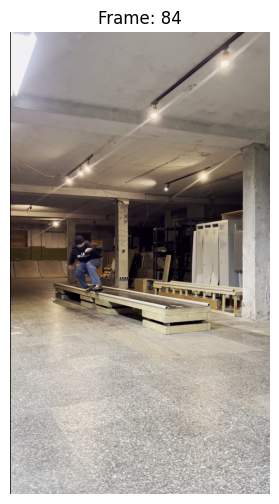

In [5]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title(f"Frame: {frame_idx}")
plt.axis("off")
plt.show()

#### Test on a frame

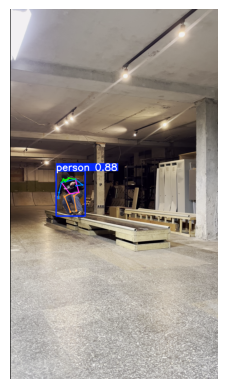

In [6]:
model = YOLO(YOLO_WEIGHTS)
frame_pose = model.predict(source=frame, device=0, imgsz=640, conf=0.25, verbose=False)

vis = frame_pose[0].plot()
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

#### Test on full video

In [ ]:
results = model.predict(
    source=clip_path.as_posix(),
    device=0,
    imgsz=640,
    conf=0.25,
    save=False,
    verbose=False,
)

WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /workspace/runs/pose/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: ultralytics.engine.results.Keypoints object
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [134, 142, 149],
         [134, 142, 149],
         [133, 141, 148]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [134, 142, 149],
         [134, 142, 149],
         [134, 142, 149]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [133, 141, 148],
         [134, 142, 149],
         [134, 142, 149]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [185, 185, 186],
         [180, 180, 181],
         [180, 180, 181]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,